# 📓 Notebook 04 – End-to-End Demo
**Version 1 | Road Damage Detection**

This notebook runs all 3 trained models on a single image and displays:
1. MobileNetV2 classification result
2. Custom CNN classification result
3. YOLOv8 detection result with bounding boxes
4. Side-by-side visual comparison
5. Final summary report

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

sys.path.insert(0, str(Path('..') / 'src'))

from models  import get_model, NUM_CLASSES
from predict import predict_classifier, predict_yolov8, CLASS_NAMES

MODELS_DIR  = Path('../models').resolve()
RESULTS_DIR = Path('../outputs/results').resolve()
DATA_ROOT   = Path('../data/prepared').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cpu


## 1. Select a Test Image

Point `IMAGE_PATH` to any road image you want to test.
The cell below auto-picks one from the val set if you don't specify one.

Auto-selected: C:\Users\Srusti\Downloads\eclipse-java-2024-09-R-win32-x86_64\project\v1\data\prepared\val\D40\D40_00000.jpg


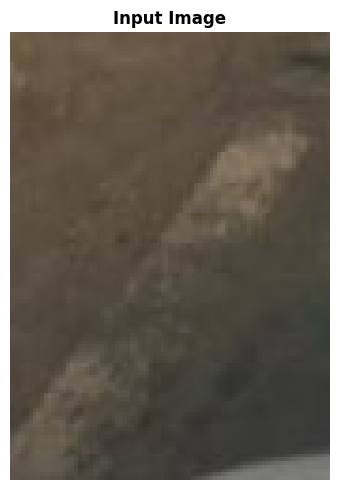

Image size: (85, 119)


In [2]:
# ── Option A: use your own image ──────────────────────────────────────────────
# IMAGE_PATH = r'C:/path/to/your/road_image.jpg'

# ── Option B: auto-pick from val set ─────────────────────────────────────────
IMAGE_PATH = None
for cls_code in ['D40', 'D20', 'D10', 'D00', 'Normal']:
    candidates = list((DATA_ROOT / 'val' / cls_code).glob('*.jpg'))
    if candidates:
        IMAGE_PATH = str(candidates[0])
        print(f'Auto-selected: {IMAGE_PATH}')
        break

if IMAGE_PATH is None:
    raise FileNotFoundError('No val images found. Run notebook 01 first.')

# Display the raw image
img = Image.open(IMAGE_PATH).convert('RGB')
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title('Input Image', fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'Image size: {img.size}')

## 2. MobileNetV2 Prediction

In [3]:
mobilenet = get_model('mobilenetv2', num_classes=NUM_CLASSES)
weights_path = MODELS_DIR / 'mobilenetv2_best.pt'

if not weights_path.exists():
    print('⚠ mobilenetv2_best.pt not found. Run notebook 03 to train first.')
else:
    mobilenet.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    mob_label, mob_conf = predict_classifier(mobilenet, IMAGE_PATH, device=DEVICE)
    print(f'MobileNetV2 → {mob_label}  ({mob_conf:.1f}% confidence)')

MobileNetV2 → D40 – Pothole  (63.2% confidence)


## 3. Custom CNN Prediction

In [4]:
cnn = get_model('customcnn', num_classes=NUM_CLASSES)
weights_path = MODELS_DIR / 'customcnn_best.pt'

if not weights_path.exists():
    print('⚠ customcnn_best.pt not found. Run notebook 03 to train first.')
else:
    cnn.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    cnn_label, cnn_conf = predict_classifier(cnn, IMAGE_PATH, device=DEVICE)
    print(f'Custom CNN  → {cnn_label}  ({cnn_conf:.1f}% confidence)')

Custom CNN  → D40 – Pothole  (47.3% confidence)


## 4. YOLOv8 Detection

In [5]:
yolo_weights = MODELS_DIR / 'yolov8n_rdd2022' / 'weights' / 'best.pt'

yolo_detections = []
if not yolo_weights.exists():
    print('⚠ YOLOv8 weights not found. Run notebook 03 YOLO training first.')
    print('  Showing detection panel as empty.')
else:
    yolo_detections = predict_yolov8(str(yolo_weights), IMAGE_PATH, conf=0.25)
    if yolo_detections:
        print(f'YOLOv8 found {len(yolo_detections)} detection(s):')
        for d in yolo_detections:
            print(f'  {d["label"]}  conf={d["confidence"]:.1f}%  bbox={[round(v,1) for v in d["bbox"]]}')
    else:
        print('YOLOv8 → No damage detected (below confidence threshold)')

⚠ YOLOv8 weights not found. Run notebook 03 YOLO training first.
  Showing detection panel as empty.


## 5. Visual Comparison – All 3 Models

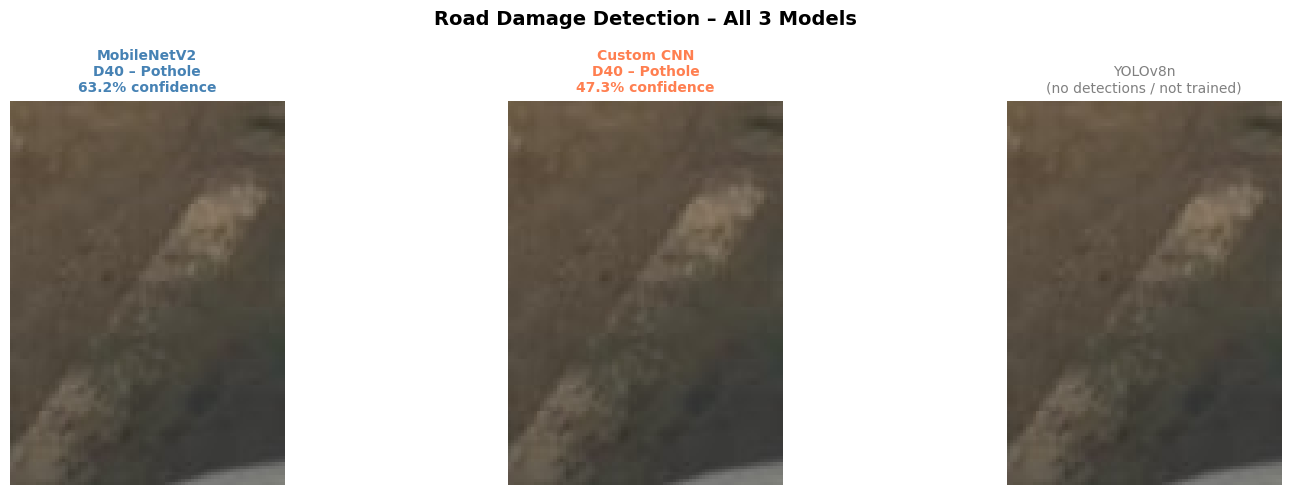

✓ Demo result saved → C:\Users\Srusti\Downloads\eclipse-java-2024-09-R-win32-x86_64\project\v1\outputs\results\demo_result.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Road Damage Detection – All 3 Models', fontsize=14, fontweight='bold')

img_np = np.array(img)

# ── Panel 1: MobileNetV2 ──────────────────────────────────────────────────────
axes[0].imshow(img_np)
axes[0].axis('off')
try:
    axes[0].set_title(f'MobileNetV2\n{mob_label}\n{mob_conf:.1f}% confidence',
                      fontsize=10, color='steelblue', fontweight='bold')
except NameError:
    axes[0].set_title('MobileNetV2\n(not trained)', fontsize=10, color='gray')

# ── Panel 2: Custom CNN ───────────────────────────────────────────────────────
axes[1].imshow(img_np)
axes[1].axis('off')
try:
    axes[1].set_title(f'Custom CNN\n{cnn_label}\n{cnn_conf:.1f}% confidence',
                      fontsize=10, color='coral', fontweight='bold')
except NameError:
    axes[1].set_title('Custom CNN\n(not trained)', fontsize=10, color='gray')

# ── Panel 3: YOLOv8 with bounding boxes ──────────────────────────────────────
axes[2].imshow(img_np)
axes[2].axis('off')

COLORS = {'D00': 'yellow', 'D10': 'cyan', 'D20': 'lime', 'D40': 'red'}

if yolo_detections:
    for det in yolo_detections:
        x1, y1, x2, y2 = det['bbox']
        color = COLORS.get(det['label'], 'white')
        rect  = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   linewidth=2, edgecolor=color, facecolor='none')
        axes[2].add_patch(rect)
        axes[2].text(x1, y1 - 4, f"{det['label']} {det['confidence']:.0f}%",
                     color=color, fontsize=8, fontweight='bold',
                     bbox=dict(facecolor='black', alpha=0.5, pad=1))
    axes[2].set_title(f'YOLOv8n\n{len(yolo_detections)} detection(s)',
                      fontsize=10, color='green', fontweight='bold')
else:
    axes[2].set_title('YOLOv8n\n(no detections / not trained)',
                      fontsize=10, color='gray')

plt.tight_layout()
out = RESULTS_DIR / 'demo_result.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Demo result saved → {out}')

## 6. Confidence Bar Chart

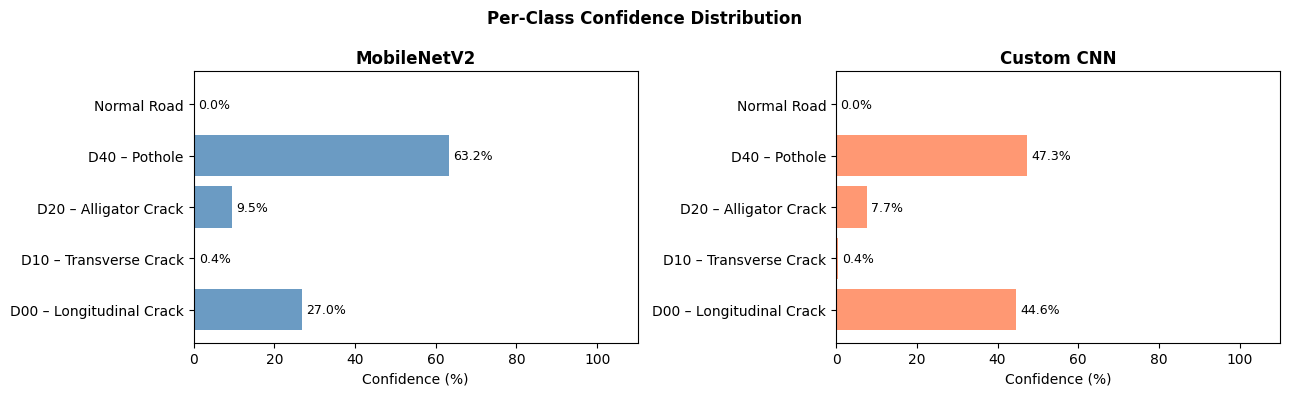

✓ Confidence chart saved → C:\Users\Srusti\Downloads\eclipse-java-2024-09-R-win32-x86_64\project\v1\outputs\results\confidence_distribution.png


In [7]:
# Show per-class probability distribution for both classifiers
from torchvision import transforms

_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

tensor = _transform(img).unsqueeze(0).to(DEVICE)
class_labels = list(CLASS_NAMES.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Per-Class Confidence Distribution', fontweight='bold')

for ax, (model_obj, model_name, color) in zip(
    axes,
    [(mobilenet, 'MobileNetV2', 'steelblue'),
     (cnn,       'Custom CNN',  'coral')]
):
    try:
        model_obj.eval()
        with torch.no_grad():
            probs = torch.softmax(model_obj(tensor), dim=1)[0].cpu().numpy()
        bars = ax.barh(class_labels, probs * 100, color=color, alpha=0.8)
        ax.set_xlim(0, 110)
        ax.set_xlabel('Confidence (%)')
        ax.set_title(model_name, fontweight='bold')
        for bar, val in zip(bars, probs * 100):
            ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9)
    except Exception:
        ax.set_title(f'{model_name}\n(not trained)', color='gray')

plt.tight_layout()
out = RESULTS_DIR / 'confidence_distribution.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'✓ Confidence chart saved → {out}')

## 7. Final Summary Report

In [8]:
print('=' * 55)
print('       ROAD DAMAGE DETECTION – FINAL REPORT')
print('=' * 55)
print(f'  Image : {Path(IMAGE_PATH).name}')
print('-' * 55)

try:
    print(f'  MobileNetV2 : {mob_label:<28} {mob_conf:.1f}%')
except NameError:
    print('  MobileNetV2 : not trained')

try:
    print(f'  Custom CNN  : {cnn_label:<28} {cnn_conf:.1f}%')
except NameError:
    print('  Custom CNN  : not trained')

if yolo_detections:
    print(f'  YOLOv8n     : {len(yolo_detections)} detection(s)')
    for d in yolo_detections:
        print(f'    → {d["label"]}  {d["confidence"]:.1f}%')
else:
    print('  YOLOv8n     : no detections / not trained')

print('-' * 55)
print('  Outputs saved to outputs/results/')
print('=' * 55)

       ROAD DAMAGE DETECTION – FINAL REPORT
  Image : D40_00000.jpg
-------------------------------------------------------
  MobileNetV2 : D40 – Pothole                63.2%
  Custom CNN  : D40 – Pothole                47.3%
  YOLOv8n     : no detections / not trained
-------------------------------------------------------
  Outputs saved to outputs/results/


## ✅ Version 1 Complete

| Notebook | Purpose | Status |
|----------|---------|--------|
| 01_dataset_preparation | Dataset setup, EDA, preprocessing | ✓ |
| 02_model_implementation | Architecture inspection, YOLO config | ✓ |
| 03_training_evaluation | Train all models, metrics, plots | ✓ |
| 04_final_demo | End-to-end inference on real image | ✓ |

---

